## Import libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import (
    cross_validate, cross_val_predict,
)
from sklearn.metrics import classification_report, confusion_matrix, make_scorer
from xgboost import XGBClassifier

## Load data

In [20]:
gex = pd.read_csv('../dataset/created/gex.csv',)
gex

,patientID,sample_id,HGNC,value,source,Method
0,LR_SMU-020,46225 PreC,PTPN20B,9.396869,Long et al.,micro-array
1,KC_19,19A,LOC286189,0.000000,Kwong et al.,RNA-seq
2,LR_MTP-034,28518_ 085G PreC,BRF1,95.004070,Long et al.,micro-array
3,YR_2420,05320132B,USP45,5.097668,Yan et al.,RNA-seq
4,LR_MTP-009,27551 PreB,MDM4,43.710980,Long et al.,micro-array
...,...,...,...,...,...,...
4162389,YR_2220,05320216B,SLC19A2,33.555115,Yan et al.,RNA-seq
4162390,YR_2096,05320093C,FUNDC2P2,1.483256,Yan et al.,RNA-seq
4162391,YR_1154,04240151B,VWA1,0.335072,Yan et al.,RNA-seq
4162392,HL_Shi-26,Pt2-baseline,CHRNA2,0.003782,Hugo et al.,RNA-seq


In [21]:
clinical = pd.read_csv(f"../dataset/created/clinical.csv", index_col='Unnamed: 0')
clinical = clinical.drop(['PFS_month', 'brain_metastasis'], axis=1)
clinical

,patientID,sex,age,AJCC_stage,M_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,source,pfs_label,cobimetinib,dabrafenib,trametinib,vemurafenib,C195W,K601I,MND,V600E,V600K,V600R
0,BS_000,male,56,IV,NaN,normal,no,no,Blateau et al.,2,0,1,1,0,0,0,0,1,0,0
1,BS_001,male,86,IV,NaN,normal,no,no,Blateau et al.,2,0,1,0,0,0,0,0,1,0,0
2,BS_002,female,47,IV,NaN,normal,no,no,Blateau et al.,2,0,1,1,0,0,0,0,1,0,0
3,BS_003,female,50,IV,NaN,NaN,no,no,Blateau et al.,0,0,0,0,1,0,0,0,1,0,0
4,BS_004,female,47,IV,NaN,elevated,no,no,Blateau et al.,1,0,1,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381,HL_Shi-40,male,47,IV,M1C,NaN,no,no,Hugo et al.,0,0,0,0,1,0,0,0,1,0,0
382,HL_Shi-41,male,39,IV,M1A,NaN,no,no,Hugo et al.,0,0,0,0,1,0,0,0,1,0,0
383,HL_Shi-42,male,84,IV,M1C,NaN,no,no,Hugo et al.,1,0,1,0,0,0,0,0,1,0,0
384,HL_Shi-43,female,41,IV,M1C,NaN,no,no,Hugo et al.,1,0,0,0,1,0,0,0,1,0,0


In [22]:
# There are DUPLICATED patientID (126 patients, 143 patients-samples)
gex_wide = gex.pivot_table(index=['patientID', 'sample_id'], columns='HGNC', values='value', aggfunc='mean')
gex_wide

,HGNC,7A5,A1BG,A1BG-AS1,A1CF,A26C3,A2BP1,A2LD1,A2M,A2M-AS1,A2ML1,...,sept-05,sept-06,sept-07,sept-08,sept-09,sept-10,sept-11,sept-12,sept-14,sept-15
patientID,sample_id,,,,,,,,,,,,,,,,,,,,,
HL_Shi-14,Pt15-baseline,NaN,4.194890,0.981249,0.003694,NaN,NaN,NaN,57.88290,0.369273,0.015522,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HL_Shi-15,Pt1-baseline,NaN,8.357535,2.648650,0.019940,NaN,NaN,NaN,68.91065,0.203056,0.184964,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HL_Shi-22,Pt5-baseline,NaN,12.442250,0.734388,0.000000,NaN,NaN,NaN,239.42500,1.056091,1.895395,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HL_Shi-23,Pt9-baseline,NaN,7.154420,1.023753,0.004563,NaN,NaN,NaN,118.44700,0.951323,0.005059,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HL_Shi-24,Pt8-baseline,NaN,9.517875,1.568550,0.002085,NaN,NaN,NaN,65.50485,0.997582,25.452050,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YR_3708,03660598B,NaN,NaN,1.600817,0.008137,NaN,NaN,NaN,NaN,42.862157,0.238685,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YR_5306,03660445B,NaN,NaN,1.260380,0.007064,NaN,NaN,NaN,NaN,17.578871,0.211784,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YR_5311,03660447B,NaN,NaN,1.969883,0.022326,NaN,NaN,NaN,NaN,3.225992,0.283971,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
clinical_gex = clinical.merge(gex_wide, on='patientID', how='inner').iloc[:, 1:]
clinical_gex

,sex,age,AJCC_stage,M_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,source,pfs_label,cobimetinib,...,sept-05,sept-06,sept-07,sept-08,sept-09,sept-10,sept-11,sept-12,sept-14,sept-15
0,male,26,IV,M1B,elevated,no,no,Yan et al.,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,female,58,IV,M1A,normal,no,no,Yan et al.,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,male,45,IV,M1A,normal,no,no,Yan et al.,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,male,48,IIIC,NaN,normal,no,no,Yan et al.,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,male,33,IV,M1C,normal,no,no,Yan et al.,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,male,61,IV,M1C,NaN,no,no,Hugo et al.,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
130,male,65,IV,M1A,NaN,no,no,Hugo et al.,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
131,male,51,IV,M1C,NaN,no,no,Hugo et al.,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
132,female,41,IV,M1C,NaN,no,no,Hugo et al.,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
# clinical_gex.to_csv('../dataset/created/clinical_gex_full.csv')

In [25]:
# Keep genes that are measured in >= 80% samples
threshold = 0.7
clinical_gex_filtered = clinical_gex.loc[:, clinical_gex.notna().sum() >= (threshold * len(clinical_gex))]
clinical_gex_filtered

,sex,age,AJCC_stage,M_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,source,pfs_label,cobimetinib,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
0,male,26,IV,M1B,elevated,no,no,Yan et al.,0,0,...,6.945362,2.407770,0.365686,0.788932,4.120387,0.075520,4.790620,34.291438,11.983017,8.707740
1,female,58,IV,M1A,normal,no,no,Yan et al.,2,0,...,8.792324,3.519765,0.505016,0.612381,3.577876,0.034480,6.395690,17.541919,12.111237,6.602669
2,male,45,IV,M1A,normal,no,no,Yan et al.,2,0,...,14.677120,1.889313,0.515572,0.639418,3.236710,0.241941,5.369550,33.843196,13.978891,12.962112
3,male,48,IIIC,NaN,normal,no,no,Yan et al.,0,1,...,5.403708,1.619349,0.613261,0.638427,2.975479,0.017479,4.664093,37.999871,13.708650,4.946914
4,male,33,IV,M1C,normal,no,no,Yan et al.,0,1,...,9.008492,0.406934,0.627742,0.976876,4.555643,0.000000,8.862486,16.650870,15.717438,13.373526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,male,61,IV,M1C,NaN,no,no,Hugo et al.,1,0,...,11.176700,23.722500,1.143155,2.338365,12.462050,0.045472,3.598195,225.415500,5.060700,6.276295
130,male,65,IV,M1A,NaN,no,no,Hugo et al.,2,0,...,3.885680,15.846150,0.725297,1.452260,7.431815,0.039194,2.045175,124.657500,5.752780,1.837855
131,male,51,IV,M1C,NaN,no,no,Hugo et al.,0,0,...,7.538723,2.265360,0.633801,2.194123,11.216233,0.017848,1.446023,110.045667,8.928340,3.211640
132,female,41,IV,M1C,NaN,no,no,Hugo et al.,1,0,...,11.598200,19.062600,2.541110,3.766443,6.655380,0.062568,5.746080,45.907933,3.015137,10.684633


## Batch correction

In [26]:
from sklearn.model_selection import train_test_split

y = clinical_gex_filtered['pfs_label']
x = clinical_gex_filtered.drop(columns=['pfs_label'])

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

X_test.head()

,sex,age,AJCC_stage,M_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,source,cobimetinib,dabrafenib,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
95,male,41,IV,M1B,normal,no,no,Long et al.,0,1,...,369.598600,270.945600,8.657087,51.588600,52.778850,6.644494,754.510500,534.950300,264.426400,314.427600
111,male,50,IV,NaN,NaN,no,no,Kwong et al.,0,1,...,10.130000,19.160000,0.220000,0.540000,3.200000,0.230000,1.060000,118.530000,4.020000,2.200000
77,female,33,IV,M1A,normal,no,no,Rizos et al.,0,1,...,127.537900,101.747200,5.322840,12.254520,103.536800,2.320265,457.538800,1326.033000,322.253800,242.953600
26,male,40,IV,M1A,normal,no,no,Yan et al.,1,0,...,17.383274,3.355188,0.077330,0.454456,3.781884,0.339204,4.552994,16.372695,10.334248,6.537761
122,female,66,IV,M1C,NaN,no,no,Hugo et al.,0,0,...,10.005750,23.566050,0.967792,3.083810,13.526600,0.077795,4.371855,135.973500,4.598850,6.422295


In [27]:
CLINICAL_COLS = ["sex", "age", "AJCC_stage", "M_stage", "LDH",
                "immunotherapy_treatment", "pre_MAPKi_treatment",
                "source", "cobimetinib", "dabrafenib", "trametinib","vemurafenib", 
                "C195W", "K601I", "MND", "R558Q", "V600E", "V600K","V600R"]
GEX_COLS = [c for c in x.columns if c not in CLINICAL_COLS]

# Clinical columns that need preprocessing
clinical_ordinal_col = ['M_stage']
clinical_categorical_cols = [
    'sex', 'AJCC_stage', 'LDH',
    'immunotherapy_treatment', 'pre_MAPKi_treatment'
]
clinical_numeric_col = ['age']
drug_braf_cols = [
    'cobimetinib', 'trametinib', 'dabrafenib', 'vemurafenib',
    'C195W', 'K601I', 'MND', 'V600E', 'V600K', 'V600R'
]
source_col = ['source']

print(f"\nClinical features: {len(CLINICAL_COLS)}")
print(f"Gene expression features: {len(GEX_COLS)}")


Clinical features: 19
Gene expression features: 17378


In [28]:
from sklearn.base import BaseEstimator, TransformerMixin
from combat.pycombat import pycombat
import numpy as np
import pandas as pd

class ComBatCorrector(BaseEstimator, TransformerMixin):
    """
    Batch correction using ComBat on gene expression columns.
    Uses the 'source' column as the batch variable.
    Imputes missing values with per-cohort median before correction
    (ComBat does not handle NaNs).
    
    Reference-batch mode: fit estimates batch parameters on training data
    using the largest cohort as reference. Transform applies the stored
    parameters; for unseen cohorts, falls back to re-estimating.
    """
    def __init__(self, gex_cols, batch_col='source', 
                 preserve_cols=None, ref_batch=None):
        self.gex_cols = gex_cols
        self.batch_col = batch_col
        self.preserve_cols = preserve_cols  # biological covariates to protect
        self.ref_batch = ref_batch
    
    def fit(self, X, y=None):
        # Store per-cohort medians for imputation on transform
        X = X.copy()
        self.cohort_medians_ = {
            cohort: X.loc[X[self.batch_col] == cohort, self.gex_cols].median()
            for cohort in X[self.batch_col].unique()
        }
        self.global_median_ = X[self.gex_cols].median()
        
        # Pick reference batch = largest cohort if not specified
        if self.ref_batch is None:
            self.ref_batch_ = X[self.batch_col].value_counts().idxmax()
        else:
            self.ref_batch_ = self.ref_batch
        
        self.fitted_ = True
        return self
    
    def transform(self, X):
        X = X.copy()
        
        # Per-cohort median imputation (ComBat cannot handle NaN)
        for cohort, medians in self.cohort_medians_.items():
            mask = X[self.batch_col] == cohort
            if mask.any():
                X.loc[mask, self.gex_cols] = (
                    X.loc[mask, self.gex_cols].fillna(medians)
                )
        # Any remaining NaN (unseen cohort) -> global median
        X[self.gex_cols] = X[self.gex_cols].fillna(self.global_median_)
        
        # ComBat expects genes as rows, samples as columns
        expr = X[self.gex_cols].T.astype(float)
        batch = X[self.batch_col].values
        
        # Optional: biological covariate matrix to preserve signal
        mod = None
        if self.preserve_cols is not None and y is not None:
            mod = X[self.preserve_cols]
        
        # Drop genes with zero variance within any batch (ComBat fails on these)
        gene_var_per_batch = X.groupby(self.batch_col)[self.gex_cols].var()
        bad_genes = gene_var_per_batch.columns[
            (gene_var_per_batch == 0).any(axis=0) |
            gene_var_per_batch.isna().any(axis=0)
        ]
        good_genes = [g for g in self.gex_cols if g not in bad_genes]
        
        corrected = pycombat(
            data=expr.loc[good_genes],
            batch=batch,
            ref_batch=self.ref_batch_,
        )
        
        # Put corrected values back into X
        X[good_genes] = corrected.T.values
        # Zero-variance genes stay as-is (or you could drop them)
        
        return X

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold

preprocessing = ColumnTransformer(
    transformers=[
        ('m_stage', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(
                categories=[['M1A', 'M1B', 'M1C']],
                handle_unknown='use_encoded_value',
                unknown_value=np.nan
            )),
        ]), clinical_ordinal_col),

        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
        ]), clinical_categorical_cols),

        ('age', SimpleImputer(strategy='median'), clinical_numeric_col),
        
        ('drug_braf', 'passthrough', drug_braf_cols),
        
        ('gex', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('scaler', StandardScaler())
        ]), GEX_COLS),
        
        ('source', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), source_col)
    ], 
)

# x_processed = clinical_preprocessor.fit_transform(x)
# x_processed = pd.DataFrame(x_processed, columns=clinical_preprocessor.get_feature_names_out())
# x_processed.columns = x_processed.columns.str.split('__').str[-1]
# x_processed

Using batch Yan et al. as a reference batch.
Found 5 batches.
Adjusting for 0 covariate(s) or covariate level(s).
Standardizing Data across genes.
Fitting L/S model and finding priors.
Finding parametric adjustments.
Adjusting the Data


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/combat/pycombat.py:158: RuntimeWarning: divide by zero encountered in divide
  change = max(np.amax(np.absolute(g_new-np.asarray(g_old))/np.asarray(g_old)), np.amax(


Using batch Yan et al. as a reference batch.
Found 5 batches.
Adjusting for 0 covariate(s) or covariate level(s).
Standardizing Data across genes.
Fitting L/S model and finding priors.
Finding parametric adjustments.
Adjusting the Data


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/combat/pycombat.py:158: RuntimeWarning: divide by zero encountered in divide
  change = max(np.amax(np.absolute(g_new-np.asarray(g_old))/np.asarray(g_old)), np.amax(




              precision    recall  f1-score   support

  Short resp       0.50      0.93      0.65        14
Intermediate       0.00      0.00      0.00         6
   Long resp       0.00      0.00      0.00         7

    accuracy                           0.48        27
   macro avg       0.17      0.31      0.22        27
weighted avg       0.26      0.48      0.34        27



/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `

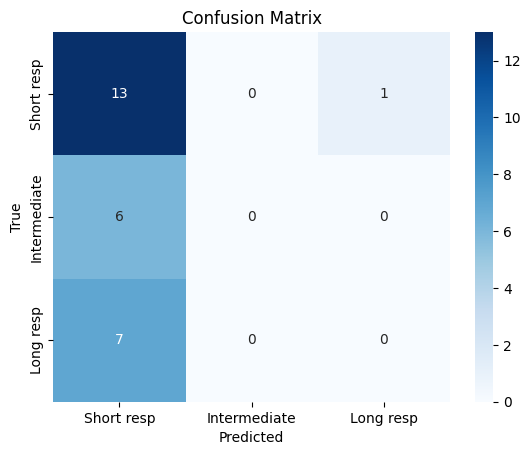

In [31]:
from sklearn.feature_selection import RFE, RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

filtering = Pipeline([
    ('variance', VarianceThreshold(threshold=0.1)),
    ('anova', SelectKBest(f_classif, k=500)),
    ('rfe', RFE(
        estimator=RandomForestClassifier(random_state=42), 
        step=1, 
        n_features_to_select=15
    ))
])

pipe = Pipeline([
    ('batch_correct', ComBatCorrector(
        gex_cols=GEX_COLS,
        batch_col='source',
        preserve_cols=None,  # or pass e.g. a copy of y as a covariate
    )),
    ('preprocessing', preprocessing),
    ('filering', filtering),
    ('clf', XGBClassifier(
            objective='multi:softprob',
            num_class=3,
            eval_metric='mlogloss',
            random_state=42,
        ))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

target_names = ['Short resp', 'Intermediate', 'Long resp']

print("\n")
print(classification_report(
    y_test, y_pred,
    target_names=target_names
))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()